# 0.5 Client Clustering and Profile Analysis

In this notebook, we analyze the clients' historical data to extract meaningful segments. We perform a two-dimensional segmentation:
1. **Profile Clustering (Behavioral):** We use K-Means on normalized hourly consumption profiles to group clients by *when* they consume electricity (e.g., daytime vs. nighttime peaks).
2. **Volume Segmentation (Size):** We use the Jenks Natural Breaks optimization to group clients by *how much* electricity they consume overall (Light, Medium, Heavy).

This *Top-Down Hierarchical* approach is an industry standard for Energy Providers. By aggregating clients into homogeneous clusters, we drastically reduce individual stochastic noise, allowing us to train robust, specialized forecasting models for specific portfolio segments.

Finally, we merge these two new categorical features directly into our pre-processed Parquet dataset.

## 1. Imports
We import the necessary libraries for data manipulation, K-Means clustering, and the Jenks Natural Breaks algorithm.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from jenkspy import jenks_breaks

## 2. Profile Clustering (K-Means)
First, we calculate the average hourly consumption profile for each client. To ensure the clustering algorithm groups clients by their *pattern* and not their *volume*, we apply row-wise normalization (MinMax scaling per client).

We use the **Elbow Method** to determine the optimal number of clusters ($k$). Based on the WCSS (Within-Cluster Sum of Squares) reduction, we select $k=5$, which provides the best balance between cluster compactness and model simplicity.

In [2]:
# We only load the columns needed for clustering to save RAM
print("Loading processed data...")
df = pd.read_parquet('../Datasets/processed_electricity_data.parquet', columns=['ClientID', 'Date', 'Hour', 'Consumption'])

# We use only data before 2014 (Training set) to define clusters
print("Filtering for training period to avoid Data Leakage...")
df_train = df[df['Date'].dt.year < 2014]

# Groupby on the filtered dataset
print("Creating average hourly profiles...")
profiles = df_train.groupby(['ClientID', 'Hour'], observed=True)['Consumption'].mean().unstack()

# Free up memory immediately
del df

Loading processed data...
Filtering for training period to avoid Data Leakage...
Creating average hourly profiles...


Normalizing profiles...
Calculating inertia for the Elbow Method...


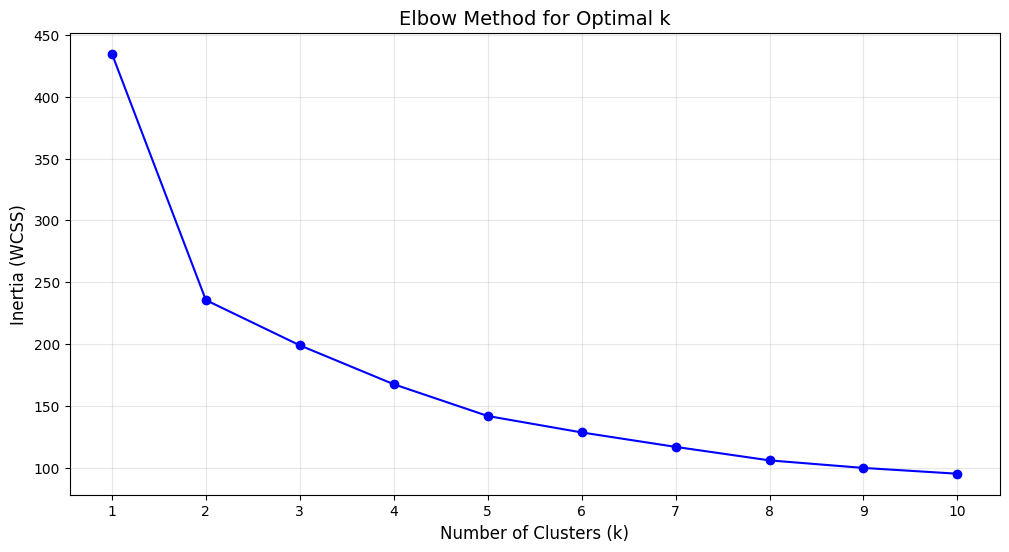

In [3]:
# Row-wise Normalization and Elbow Method
print("Normalizing profiles...")
scaler = MinMaxScaler()

# MinMaxScaler scales features (columns) by default. 
# We transpose the matrix (.T) to scale each client (row) individually, and then transpose it back to restore the original shape.
profiles_scaled = scaler.fit_transform(profiles.T).T

inertia = []
K_range = range(1, 11)

print("Calculating inertia for the Elbow Method...")
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(profiles_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# K-Means Clustering (k=5)
n_clusters = 5
print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(profiles_scaled)

client_clusters = pd.DataFrame({
    'ClientID': profiles.index,
    'Cluster':  cluster_labels
})

Running K-Means with 5 clusters...


The resulting plot helps us identify consumer types based strictly on historical training data (pre-2014). K-Means assigns cluster IDs dynamically, but looking at the hourly distribution, the behavioral patterns are distinct:

- **Cluster 0 (Blue - 161 clients)**: Standard Daytime Office/Business. This group shows a steady plateau during standard working hours (9:00 AM to 6:00 PM) and sharply drops after 6:00 PM when employees leave for the day.

- **Cluster 1 (Orange - 87 clients)**: Standard Residential. Consumption rises in the morning and remains high throughout the evening until late night (around 10:00 PM), reflecting typical household behavior where peak energy use occurs after work hours.

- **Cluster 2 (Green - 36 clients)**: Split-Shift/Siesta Profile. These clients have a sharp peak at noon followed by a visible dip around 2:00 PM - 3:00 PM, a classic "siesta" signature common in Portuguese commercial districts.

- **Cluster 3 (Red - 71 clients)**: Extended Hours Commercial / Mixed-Use. Similar to the residential shape but starting earlier and maintaining a higher, broader plateau. This points to businesses open late (restaurants, retail) or mixed-use buildings.

- **Cluster 4 (Purple - 15 clients)**: Night-Shift Industrial. This unique group shows peak consumption from midnight to 6:00 AM, with a significant drop during daylight hours.

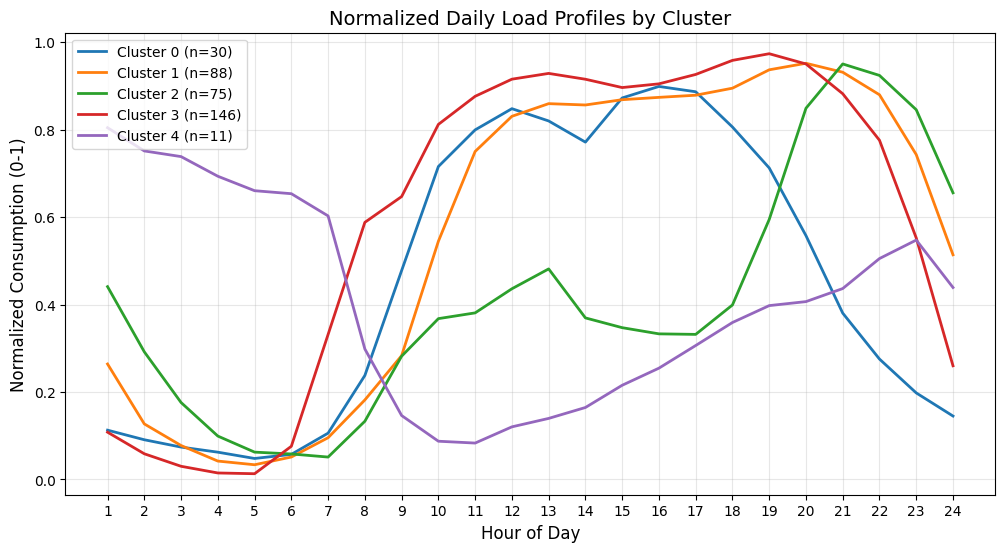

In [5]:
# Cluster Profile Visualization
plt.figure(figsize=(12, 6))
for i in range(n_clusters):
    cluster_mean = profiles_scaled[cluster_labels == i].mean(axis=0)
    plt.plot(range(1, 25), cluster_mean, label=f'Cluster {i} (n={sum(cluster_labels == i)})', linewidth=2)

plt.title('Normalized Daily Load Profiles by Cluster', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Normalized Consumption (0-1)', fontsize=12)
plt.xticks(range(1, 25))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Volume Segmentation (Jenks Natural Breaks)

Behavioral clustering (above) groups clients by *when* they consume. Here we segment them by *how much* they consume on average — splitting into Light, Medium, and Heavy using Jenks natural breaks on the log-transformed mean consumption.

Since the distribution is heavily right-skewed, a log transform is applied first so the algorithm finds breaks that are meaningful in relative (multiplicative) terms rather than absolute ones.

In [ ]:
# Calculate historical mean consumption per client.
# We strictly use 'df_train' to prevent Data Leakage from the test set.
client_means = df_train.groupby('ClientID', observed=True)['Consumption'].mean()

# Electricity consumption is heavily skewed (long-tail distribution). 
# We apply a log1p transformation (log(1+x)) to normalize the variance before passing it to the Jenks algorithm, ensuring better break points.
log_means = np.log1p(client_means)

# Calculate Jenks Natural Breaks for 3 classes (Light, Medium, Heavy)
breaks    = jenks_breaks(log_means.values, n_classes=3)
light_threshold_log = breaks[1]
heavy_threshold_log = breaks[2]

# Revert the thresholds back to the original scale to interpret the thresholds in real-world units.
light_threshold     = np.expm1(breaks[1])
heavy_threshold     = np.expm1(breaks[2])

print(f"Light consumers:  below {light_threshold:.2f} kW average")
print(f"Medium consumers: {light_threshold:.2f} to {heavy_threshold:.2f} kW average")
print(f"Heavy consumers:  above {heavy_threshold:.2f} kW average")

def categorize_client(mean_val):
    """
    Helper function to classify clients based on the calculated log thresholds
    """
    log_val = np.log1p(mean_val)
    if log_val <= light_threshold_log:
        return 'Light'
    elif log_val <= heavy_threshold_log:
        return 'Medium'
    else:
        return 'Heavy'

# Apply the categorization to the entire client base
client_categories = client_means.apply(categorize_client).rename('Consumer_Category')

print(f"\nCategory distribution:")
print(client_categories.value_counts())

Light consumers:  below 62.79 kW average
Medium consumers: 62.79 to 392.05 kW average
Heavy consumers:  above 392.05 kW average

Category distribution:
Consumer_Category
Medium    190
Heavy      85
Light      75
Name: count, dtype: int64


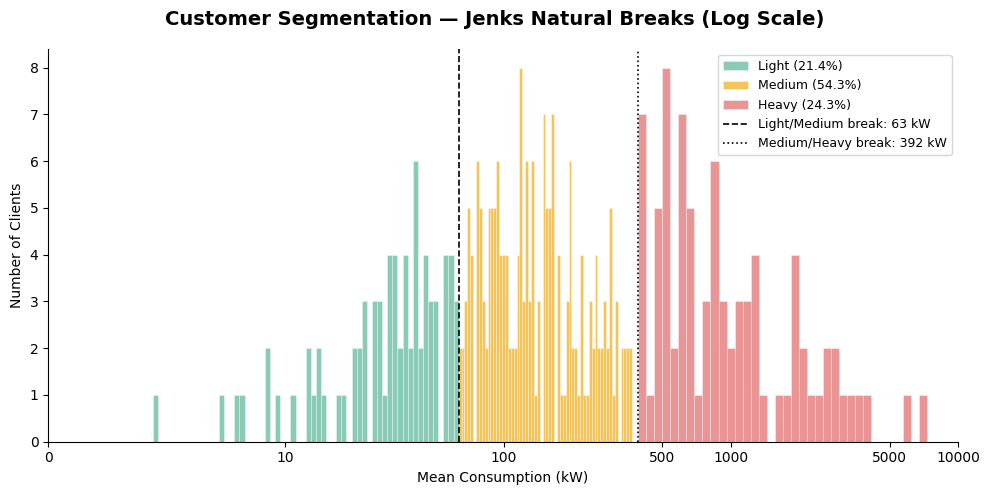

In [ ]:

# Merge the mean consumption values with their new categorical labels
cat_labels = client_categories.reset_index()
cat_labels.columns = ['ClientID', 'Consumer_Category']
plot_df = client_means.reset_index()
plot_df.columns = ['ClientID', 'MeanConsumption']
plot_df = plot_df.merge(cat_labels, on='ClientID').sort_values('MeanConsumption').reset_index(drop=True)

# Calculate the percentage distribution for the chart legend
pcts   = plot_df['Consumer_Category'].value_counts(normalize=True) * 100
colors = {
    'Light': '#4CAF93', 
    'Medium': '#F0A500', 
    'Heavy': '#E05C5C'
    }

# Jenks Visualization: Histogram with log-scale x-axis
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Customer Segmentation — Jenks Natural Breaks (Log Scale)', fontsize=14, fontweight='bold')

for label, color in colors.items():
    vals = np.log1p(plot_df.loc[plot_df['Consumer_Category'] == label, 'MeanConsumption'])
    ax.hist(vals, bins=60, color=color, alpha=0.65, label=f"{label} ({pcts[label]:.1f}%)",
            edgecolor='white', linewidth=0.4)

ax.axvline(light_threshold_log, color='black', linestyle='--', linewidth=1.2,
           label=f'Light/Medium break: {light_threshold:.0f} kW')
ax.axvline(heavy_threshold_log, color='black', linestyle=':', linewidth=1.2,
           label=f'Medium/Heavy break: {heavy_threshold:.0f} kW')

tick_vals_kw  = [0, 10, 100, 500, 1000, 5000, 10000]
tick_vals_log = np.log1p(tick_vals_kw)
ax.set_xticks(tick_vals_log)
ax.set_xticklabels([str(v) for v in tick_vals_kw])
ax.set_xlim(np.log1p(0), np.log1p(10000))

ax.set_xlabel('Mean Consumption (kW)')
ax.set_ylabel('Number of Clients')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Merging and Saving to Parquet
We merge both the `Cluster` (behavioral) and `Consumer_Category` (volume) assignments directly into our main `processed_electricity_data.parquet` file. 

This ensures our downstream forecasting models have immediate access to these engineered features, while maintaining the memory efficiency of `category` data types.

In [ ]:
print("Loading existing Parquet dataset...")
parquet_path = '../Datasets/processed_electricity_data.parquet'
df_parquet = pd.read_parquet(parquet_path)

# Drop columns if they already exist (to allow safe re-runs of this notebook)
columns_to_drop = [col for col in ['Cluster', 'Consumer_Category'] if col in df_parquet.columns]
if columns_to_drop:
    df_parquet = df_parquet.drop(columns=columns_to_drop)

print("Merging Profile Clusters and Volume Categories...")

# Merge K-Means Clusters
df_parquet = df_parquet.merge(
    client_clusters, 
    on='ClientID', 
    how='left')

# Merge Jenks Volume Categories
df_parquet = df_parquet.merge(
    client_categories.reset_index(),
    on='ClientID',
    how='left'
)

# Convert to categorical for memory optimization
df_parquet['Cluster'] = df_parquet['Cluster'].astype('category')
df_parquet['Consumer_Category'] = df_parquet['Consumer_Category'].astype('category')

print("Saving updated dataset...")
df_parquet.to_parquet(parquet_path, index=False)

print("Success! The parquet file now contains both 'Cluster' and 'Consumer_Category'.")

Loading existing Parquet dataset...
Merging Profile Clusters and Volume Categories...
Saving updated dataset...
Success! The parquet file now contains both 'Cluster' and 'Consumer_Category'.
